## analysing data

In [112]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [113]:
df = pd.read_csv("india_housing_prices1.csv")
df.columns
df.shape
df.sort_values(by=["Size_in_SqFt","Price_in_Rupee"],inplace=True)
df.to_csv("india_housing_prices1.csv",index=False)

In [114]:
df.info()
df.fillna(0)
df.isnull().sum()*100
df.keys()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   City            291 non-null    object
 1   BHK             291 non-null    int64 
 2   Size_in_SqFt    291 non-null    int64 
 3   Price_in_Rupee  291 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 9.2+ KB


,City,BHK,Size_in_SqFt,Price_in_Rupee
0,Delhi,1,530,4240000
1,Aurangabad,1,550,4400000
2,Vishakhapatnam,1,550,4400000
3,Chennai,1,560,4480000
4,Mysore,3,560,4480000
...,...,...,...,...
286,Gaya,5,3400,27200000
287,Jamshedpur,4,3570,28560000
288,Varanasi,5,3650,29200000
289,Vellore,5,4235,33880000


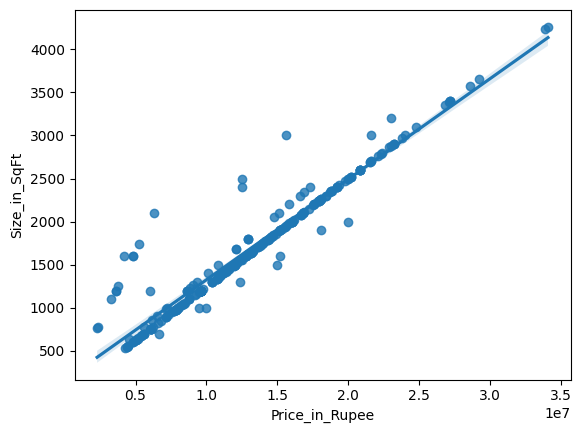

In [115]:

sns.regplot(data=df,x = "Price_in_Rupee" , y="Size_in_SqFt")
plt.show()

## encoding categorical Values

In [116]:
df.head(5)

,City,BHK,Size_in_SqFt,Price_in_Rupee
0,Delhi,1,530,4240000
1,Aurangabad,1,550,4400000
2,Vishakhapatnam,1,550,4400000
3,Chennai,1,560,4480000
4,Mysore,3,560,4480000


In [117]:
from sklearn.preprocessing import LabelEncoder 
df_encoded = df.copy()
le = LabelEncoder()
df_encoded["City"] = le.fit_transform(df_encoded["City"])
df_encoded.head()


,City,BHK,Size_in_SqFt,Price_in_Rupee
0,15,1,530,4240000
1,6,1,550,4400000
2,67,1,550,4400000
3,11,1,560,4480000
4,46,3,560,4480000


## Feature Scalling

In [118]:
from sklearn.preprocessing import StandardScaler
s_scaler =StandardScaler()

input_data = df_encoded.iloc[:,:-1]
input_data = pd.DataFrame(s_scaler.fit_transform(input_data),columns=input_data.columns)

output_data = df_encoded["Price_in_Rupee"]

input_data.head()


,City,BHK,Size_in_SqFt
0,-0.967777,-1.321978,-1.595425
1,-1.417255,-1.321978,-1.567531
2,1.629208,-1.321978,-1.567531
3,-1.167545,-1.321978,-1.553584
4,0.580426,0.094949,-1.553584


## Model Training

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=42)


In [120]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)
model.score(X_train,y_train)*100 , model.score(X_test,y_test)*100
y_pred = model.predict(X_test)


<Axes: >

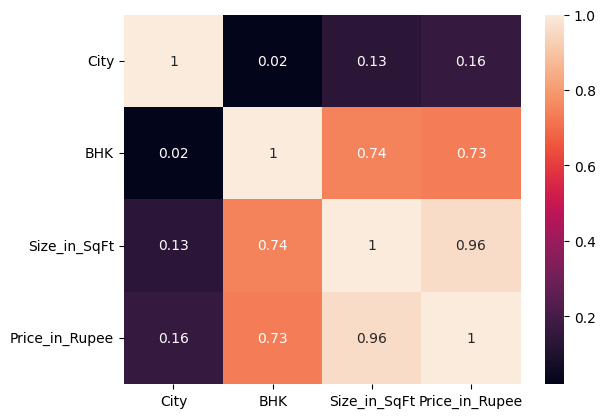

In [121]:
sns.heatmap(data=df_encoded.corr(),annot=True)

## Model Evaluation

In [122]:
#r sqaure value
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 
predictedPriceTrain=model.predict(X_train)
r2_train = r2_score(y_train,predictedPriceTrain)


predictedPriceTest=model.predict(X_test)
r2_test = r2_score(y_test,predictedPriceTest)
print (f"Model Score is ({r2_train},{r2_test})")

Model Score is (0.9265459609147422,0.9120800170524617)


## Building a predictive System


In [123]:
try:
    inputCity = str(input("Enter Name of City:"))
    inputSize = int(input("Enter size of house in sqft:"))
    inputbhk = int(input("Enter how much bhk house you  want"))
    user_input_df = pd.DataFrame([{
        "City":inputCity.strip().title(),
        "BHK":inputbhk,
        "Size_in_SqFt":inputSize
    }])
    user_input_df["City"] = le.transform([user_input_df["City"]])[0]
    user_input_scaled = s_scaler.transform(user_input_df)
    
    prediction = model.predict(user_input_scaled)[0]

    print(f"Your Predicted Price for house will be {prediction}")
    
except Exception as e:
    print("An error occured",e)

Your Predicted Price for house will be 7481292.592907889


c:\Users\Lenovo\PythonProjectAdityaSharma\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\Lenovo\PythonProjectAdityaSharma\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
